# Hall Effect Data Explorer

HDF5 데이터를 불러와서 간단히 시각화합니다.

In [43]:
from pathlib import Path

import h5py
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = Path("..") / "data" / "hdf5"
CALIB_H5 = DATA_DIR / "calibration.h5"
VOLTAGE_H5 = DATA_DIR / "voltage_measurements.h5"

## 1. Calibration: Coil Current vs B-field

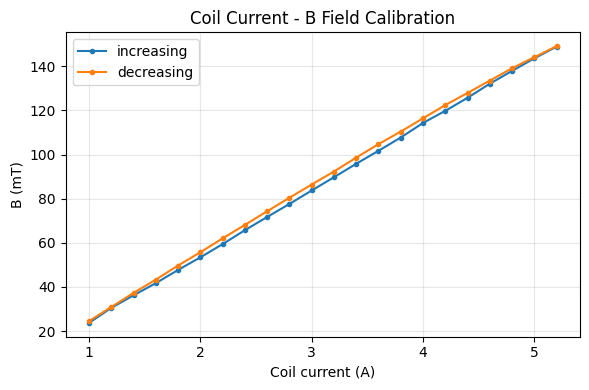

In [44]:
with h5py.File(CALIB_H5, "r") as hf:
    fig, ax = plt.subplots(figsize=(6, 4))
    for direction in ["increasing", "decreasing"]:
        grp = hf[f"current_field/{direction}"]
        I = grp["coil_current_A"][:]
        B = grp["B_field_mT"][:]
        ax.plot(I, B, "o-", markersize=3, label=direction)
    ax.set_xlabel("Coil current (A)")
    ax.set_ylabel("B (mT)")
    ax.set_title("Coil Current - B Field Calibration")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

### 1-1. Calibration Linear Fit

Increasing / Decreasing 각각 $B = a \cdot I + b$ 로 선형 피팅

[increasing]
  B = 29.9438 * I + (-6.0758)  [mT]
  residual std = 0.3121 mT

[decreasing]
  B = 29.9252 * I + (-4.0817)  [mT]
  residual std = 0.8839 mT



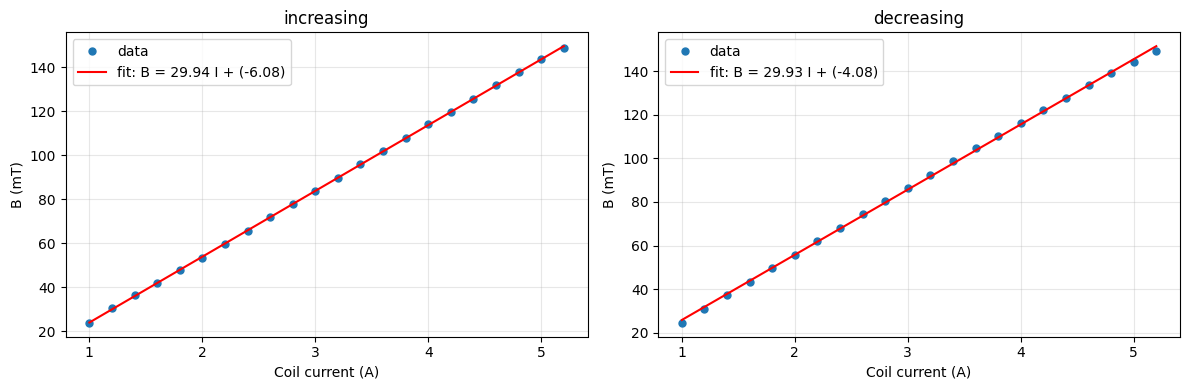

fit_results: {'increasing': {'a': np.float64(29.94381705251271), 'b': np.float64(-6.075832862789384)}, 'decreasing': {'a': np.float64(29.925183512140034), 'b': np.float64(-4.081705251270486)}}


In [45]:
with h5py.File(CALIB_H5, "r") as hf:
    fit_results = {}

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    for ax, direction in zip(axes, ["increasing", "decreasing"]):
        grp = hf[f"current_field/{direction}"]
        I = grp["coil_current_A"][:]
        B = grp["B_field_mT"][:]

        coeffs = np.polyfit(I, B, 1)
        a, b = coeffs
        fit_results[direction] = {"a": a, "b": b}

        I_fit = np.linspace(I.min(), I.max(), 100)
        B_fit = np.polyval(coeffs, I_fit)

        B_pred = np.polyval(coeffs, I)
        residuals = B - B_pred

        ax.plot(I, B, "o", markersize=5, label="data")
        ax.plot(I_fit, B_fit, "-", color="red",
                label=f"fit: B = {a:.2f} I + ({b:.2f})")
        ax.set_xlabel("Coil current (A)")
        ax.set_ylabel("B (mT)")
        ax.set_title(f"{direction}")
        ax.legend()
        ax.grid(True, alpha=0.3)

        print(f"[{direction}]")
        print(f"  B = {a:.4f} * I + ({b:.4f})  [mT]")
        print(f"  residual std = {np.std(residuals):.4f} mT")
        print()

    plt.tight_layout()
    plt.show()

print("fit_results:", fit_results)

## 2. Ramp Detection & Steady-State Extraction

샘플 전류(`sample_current_A`)의 ramp-up 구간 **시작**과 **끝**을 검출합니다.
- ramp start: smoothed signal이 peak의 5%를 처음 넘는 지점
- ramp end: smoothed signal이 peak의 90%를 처음 넘는 지점
- steady-state: ramp end 이후 plateau 구간

Ge(undoped)는 제외하고 **Ge-n, Ge-p**만 처리합니다.

In [46]:
DOPED_SAMPLES = ["Ge-n", "Ge-p"]


def smooth_signal(signal: np.ndarray, win: int = 20) -> np.ndarray:
    """Rolling-mean smoothing to suppress noise."""
    clean = np.nan_to_num(signal, nan=0.0)
    win = min(win, len(clean) // 5)
    if win > 1:
        kernel = np.ones(win) / win
        return np.convolve(clean, kernel, mode="same")
    return clean


def find_ramp_bounds(signal: np.ndarray,
                     start_frac: float = 0.05,
                     end_frac: float = 0.90) -> tuple[int, int]:
    """Return (ramp_start, ramp_end) indices."""
    sm = smooth_signal(signal)
    peak = np.max(sm)
    if peak <= 0:
        return 0, 0
    ramp_start = int(np.argmax(sm > start_frac * peak))
    ramp_end = int(np.argmax(sm > end_frac * peak))
    return ramp_start, ramp_end


ramp_data = {}

with h5py.File(VOLTAGE_H5, "r") as hf:
    for mtype in ["transverse", "longitudinal"]:
        for sample in DOPED_SAMPLES:
            sample_grp = hf[f"{mtype}/{sample}"]
            for coil_key in sorted(sample_grp.keys(), key=lambda k: int(k.split("_")[1])):
                grp = sample_grp[coil_key]
                t = grp["time_s"][:]
                I = grp["sample_current_A"][:]
                V = grp["voltage_V"][:]
                I_coil = grp.attrs["coil_current_A"]

                ramp_start, ramp_end = find_ramp_bounds(I)

                V_ss = V[ramp_end:]
                I_ss = I[ramp_end:]
                V_valid = V_ss[~np.isnan(V_ss)]
                I_valid = I_ss[~np.isnan(I_ss)]

                ramp_data[(mtype, sample, coil_key)] = {
                    "I_coil_A": I_coil,
                    "ramp_start": ramp_start,
                    "ramp_end": ramp_end,
                    "n_total": len(t),
                    "n_ss": len(t) - ramp_end,
                    "V_mean": np.mean(V_valid) if len(V_valid) else np.nan,
                    "V_std": np.std(V_valid) if len(V_valid) else np.nan,
                    "I_mean": np.mean(I_valid) if len(I_valid) else np.nan,
                }

print(f"Detected ramp bounds for {len(ramp_data)} measurements\n")
for key in list(ramp_data.keys())[:8]:
    d = ramp_data[key]
    print(f"  {key[0]:12s}/{key[1]:4s}/{key[2]:8s}  "
          f"ramp=[{d['ramp_start']:4d}, {d['ramp_end']:4d}] / {d['n_total']:4d}  "
          f"V_mean={d['V_mean']:+.6f}")

Detected ramp bounds for 88 measurements

  transverse  /Ge-n/coil_10   ramp=[1121, 1242] / 1813  V_mean=+0.002148
  transverse  /Ge-n/coil_12   ramp=[1056, 1142] / 1554  V_mean=+0.003525
  transverse  /Ge-n/coil_14   ramp=[2644, 2814] / 3245  V_mean=+0.004511
  transverse  /Ge-n/coil_16   ramp=[1741, 1966] / 2292  V_mean=+0.005707
  transverse  /Ge-n/coil_18   ramp=[2563, 2775] / 3291  V_mean=+0.006942
  transverse  /Ge-n/coil_20   ramp=[3001, 3166] / 3979  V_mean=+0.008063
  transverse  /Ge-n/coil_22   ramp=[3042, 3143] / 3951  V_mean=+0.009353
  transverse  /Ge-n/coil_24   ramp=[1313, 1355] / 2104  V_mean=+0.010469


### 2-1. Ramp Cut Verification (All Measurements)

모든 코일 전류에 대해 ramp start(녹색) / ramp end(빨강) 경계를 표시

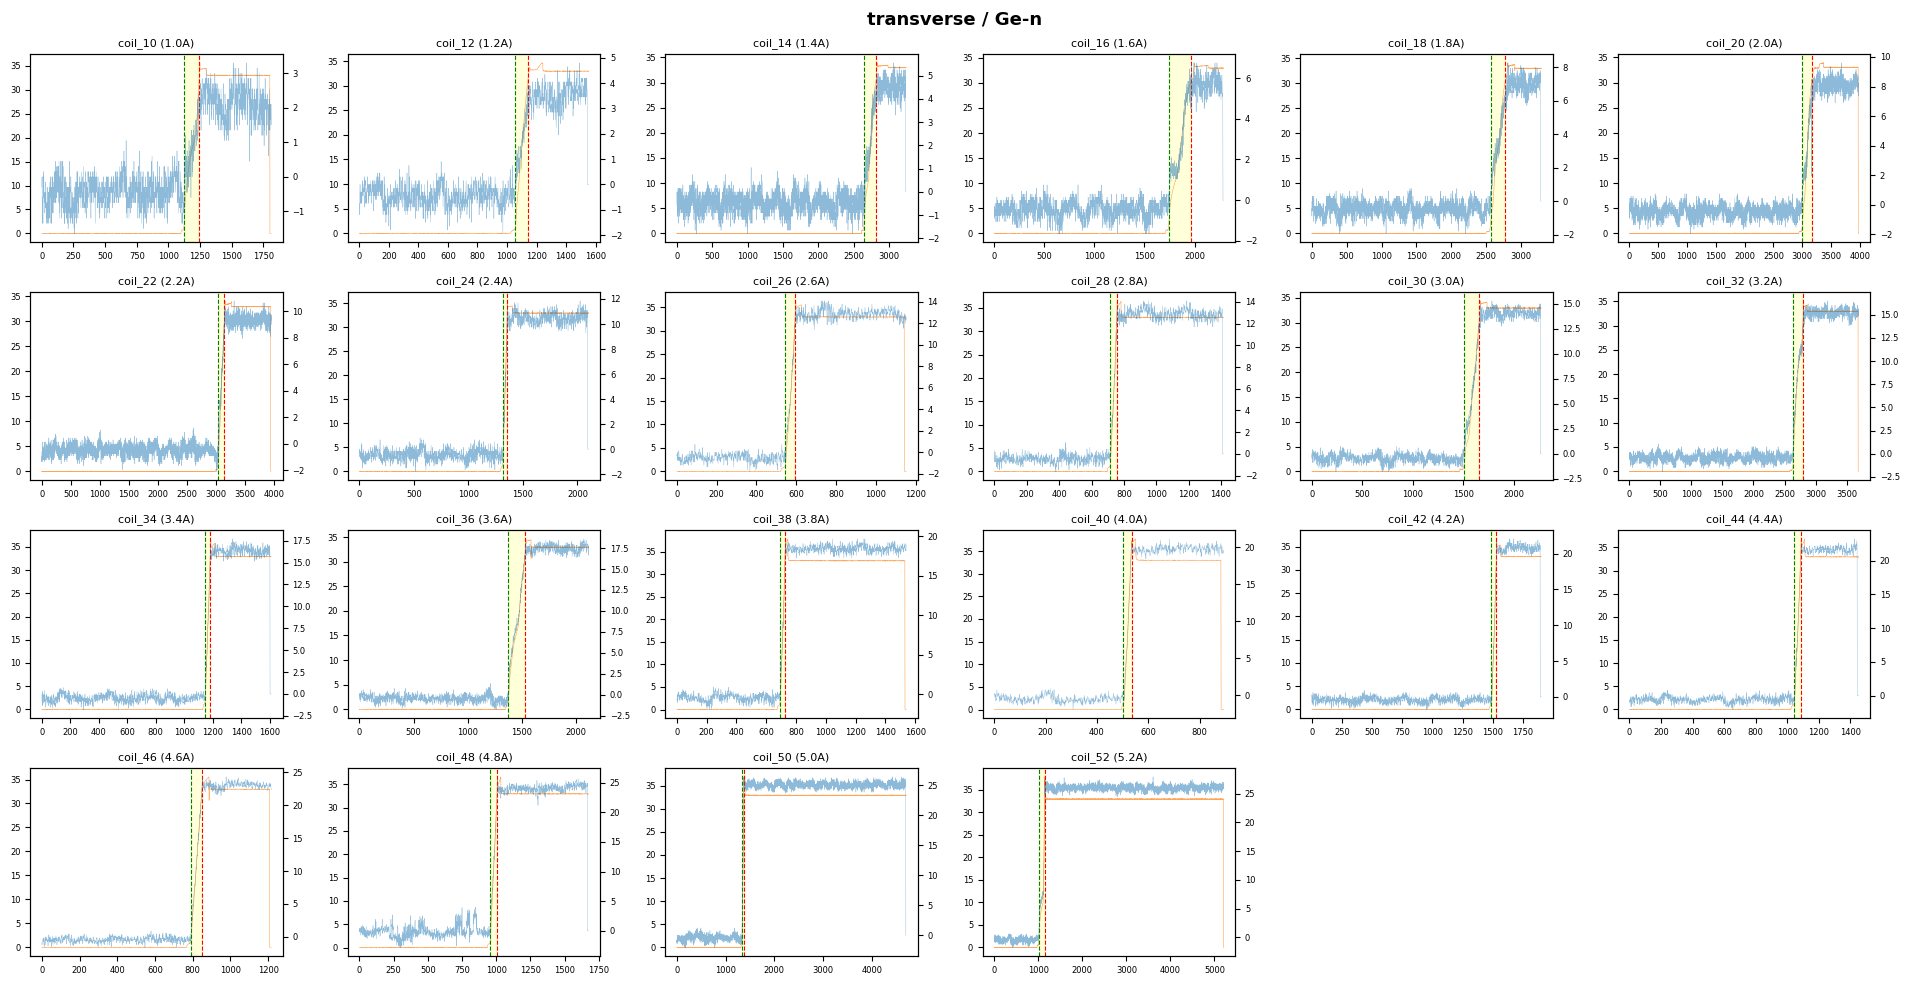

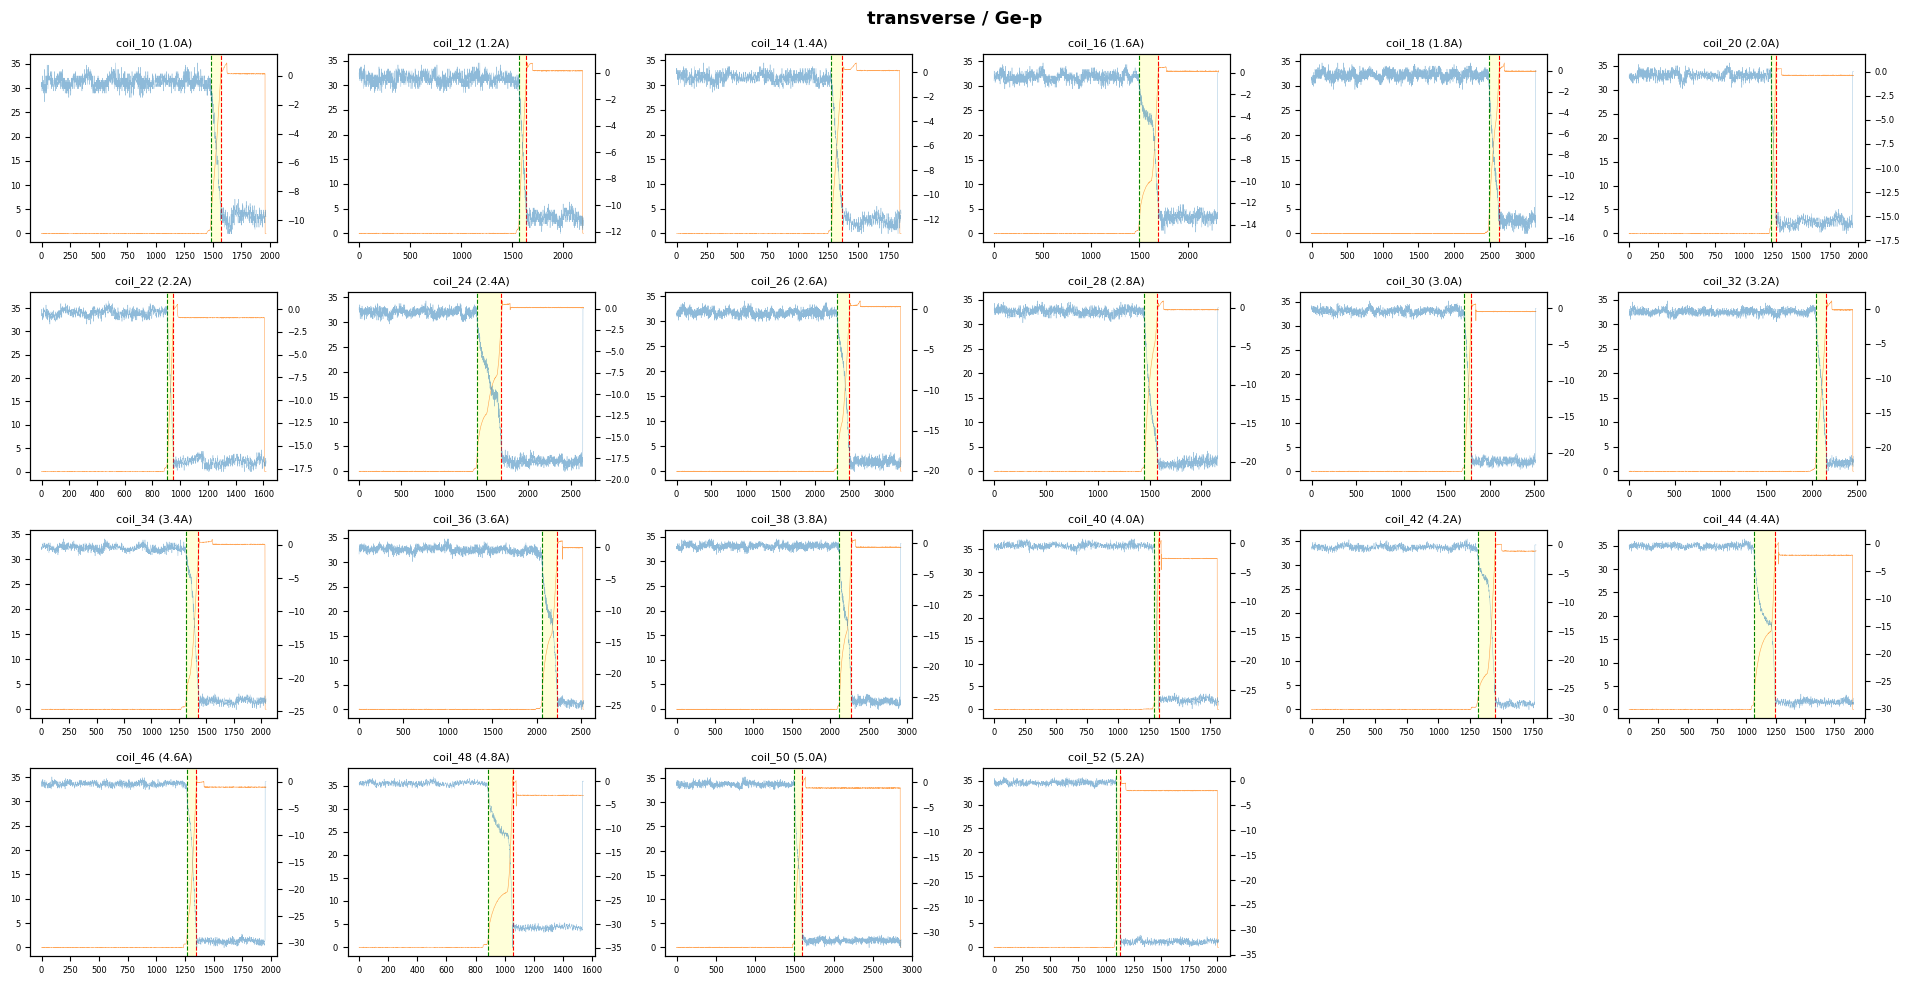

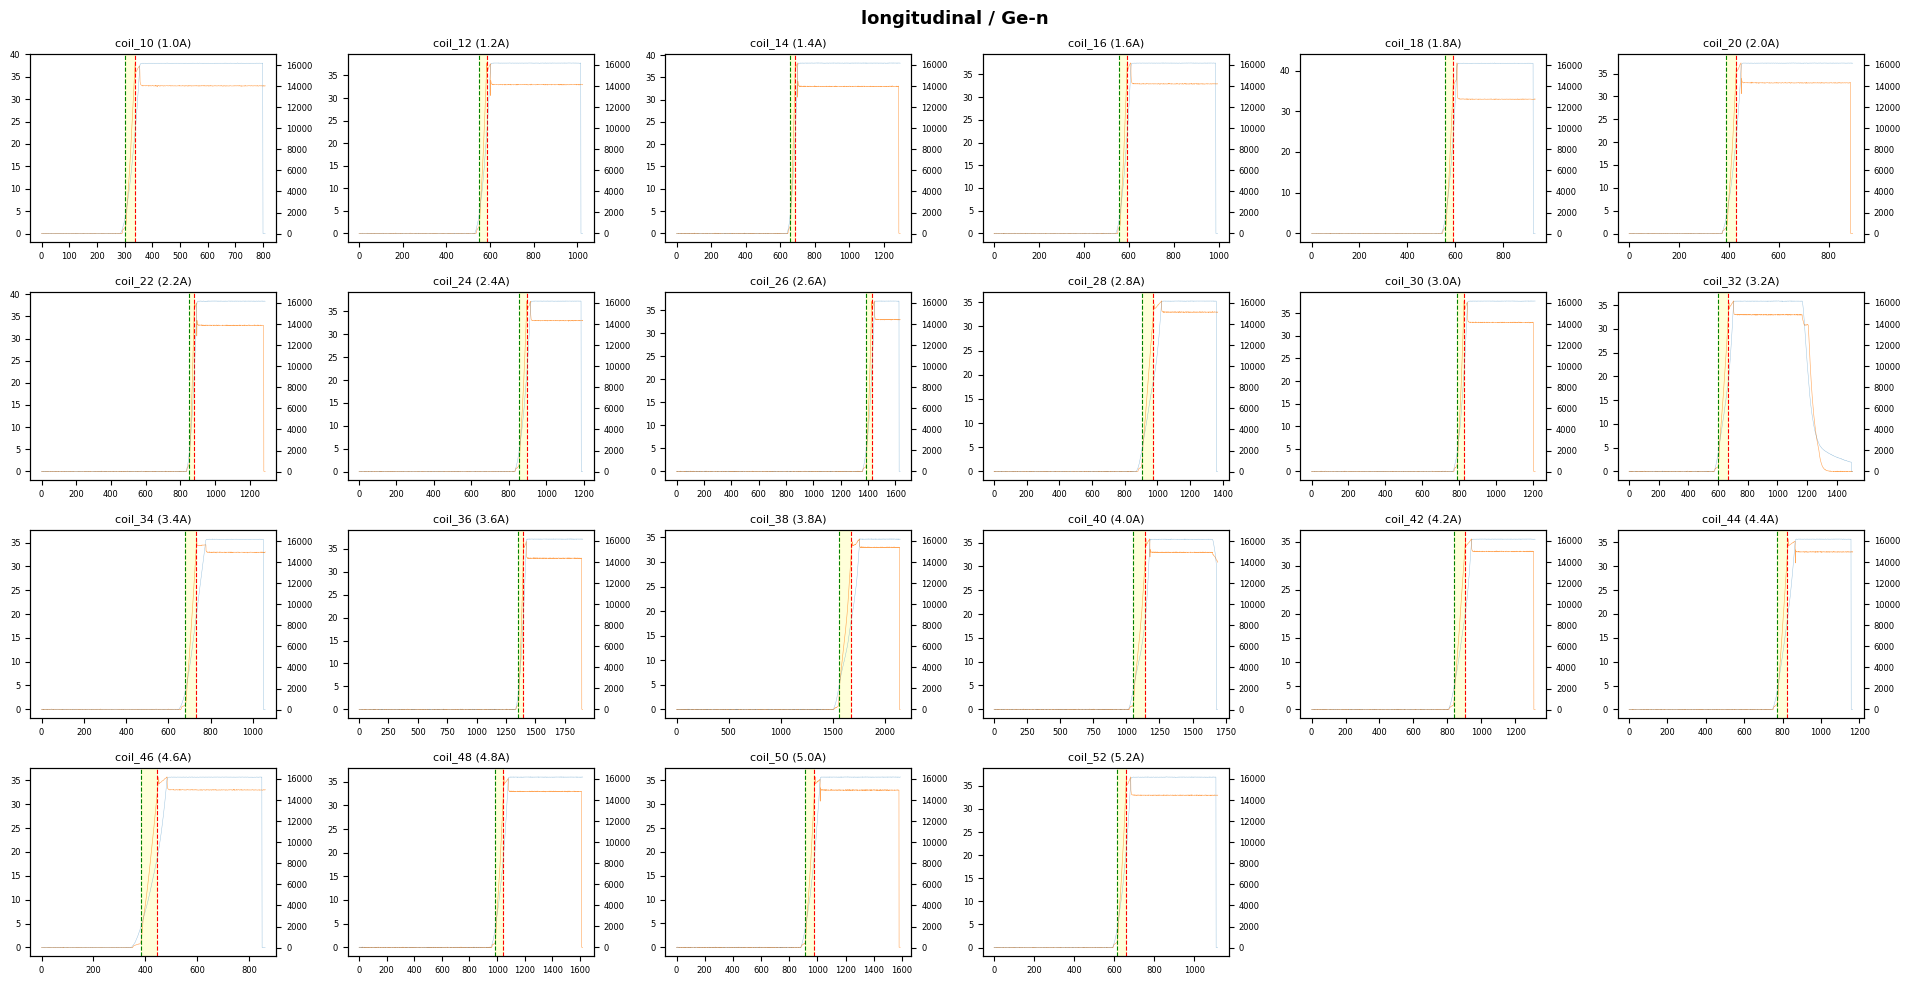

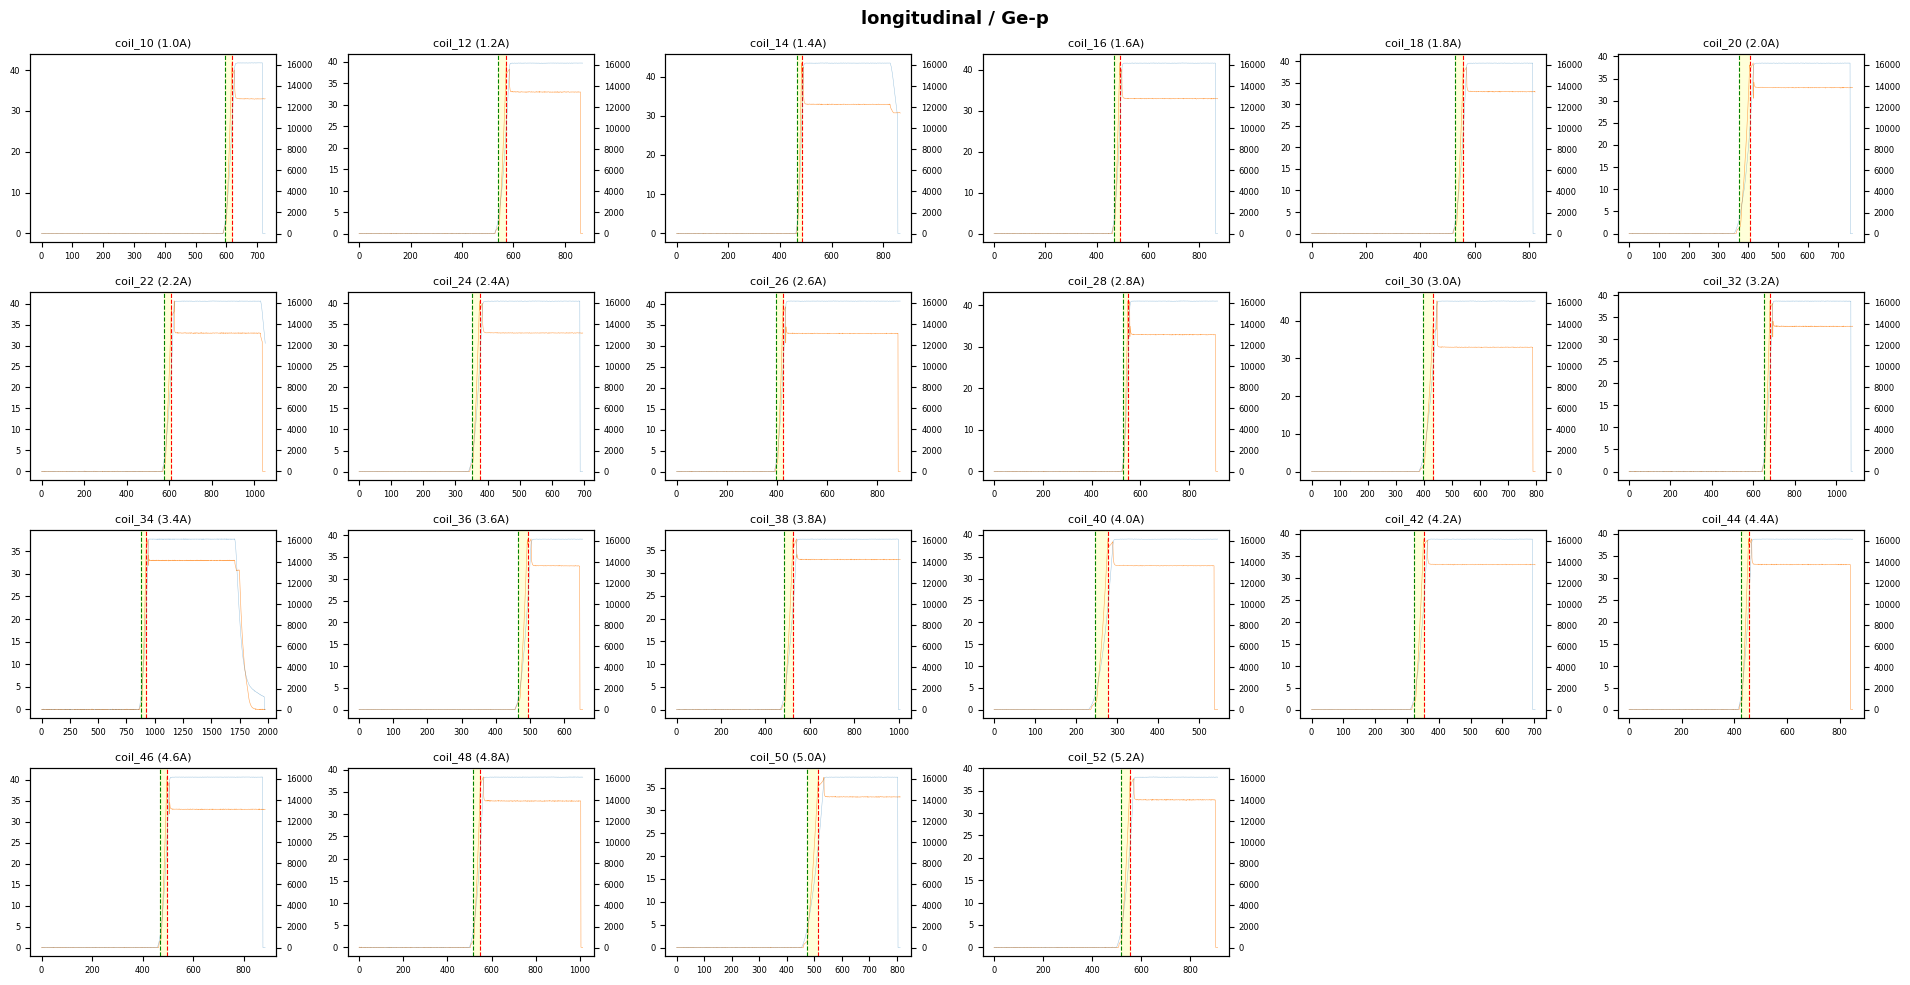

In [47]:
with h5py.File(VOLTAGE_H5, "r") as hf:
    for mtype in ["transverse", "longitudinal"]:
        for sample in DOPED_SAMPLES:
            sample_grp = hf[f"{mtype}/{sample}"]
            coil_keys = sorted(sample_grp.keys(), key=lambda k: int(k.split("_")[1]))
            n = len(coil_keys)
            ncols = 6
            nrows = (n + ncols - 1) // ncols

            fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 2.5 * nrows))
            axes = np.atleast_2d(axes)
            fig.suptitle(f"{mtype} / {sample}", fontsize=13, fontweight="bold")

            for idx, coil_key in enumerate(coil_keys):
                r, c = divmod(idx, ncols)
                ax = axes[r, c]

                grp = sample_grp[coil_key]
                t = grp["time_s"][:] * 1e3
                I = grp["sample_current_A"][:]
                V = grp["voltage_V"][:]

                d = ramp_data[(mtype, sample, coil_key)]
                rs, re = d["ramp_start"], d["ramp_end"]

                ax.plot(t, np.nan_to_num(I, nan=0) * 1e3,
                        linewidth=0.4, color="C1", alpha=0.7)
                ax_v = ax.twinx()
                ax_v.plot(t, np.nan_to_num(V, nan=0) * 1e3,
                          linewidth=0.3, color="C0", alpha=0.5)

                ax.axvline(t[rs], color="green", ls="--", lw=0.8)
                ax.axvline(t[re], color="red", ls="--", lw=0.8)
                ax.axvspan(t[rs], t[re], color="yellow", alpha=0.15)

                ax.set_title(f"{coil_key} ({d['I_coil_A']:.1f}A)", fontsize=8)
                ax.tick_params(labelsize=6)
                ax_v.tick_params(labelsize=6)

            for idx in range(n, nrows * ncols):
                r, c = divmod(idx, ncols)
                axes[r, c].set_visible(False)

            plt.tight_layout()
            plt.show()

## 3. B-field vs Voltage

캘리브레이션 linear fit ($B = a \cdot I_\text{coil} + b$)을 이용해 코일 전류를 자기장으로 변환한 뒤,
steady-state 구간의 평균 transverse 전압과 longitudinal 전압을 B-field에 대해 플롯합니다.

아래 셀에서 `calib_slope`, `calib_intercept` 값을 직접 수정할 수 있습니다.

In [48]:
# ---- Calibration parameters (edit here) ----
# Increasing / decreasing 평균을 기본값으로 사용
calib_slope = np.mean([fit_results["increasing"]["a"],
                       fit_results["decreasing"]["a"]])      # mT / A
calib_intercept = np.mean([fit_results["increasing"]["b"],
                           fit_results["decreasing"]["b"]])  # mT

def I_coil_to_B(I_coil_A: float) -> float:
    """Convert coil current (A) to magnetic field (mT) using linear calibration."""
    return calib_slope * I_coil_A + calib_intercept

print(f"Calibration: B = {calib_slope:.4f} * I_coil + ({calib_intercept:.4f})  [mT]")
print(f"  e.g. I_coil=3.0 A  ->  B = {I_coil_to_B(3.0):.2f} mT")

Calibration: B = 29.9345 * I_coil + (-5.0788)  [mT]
  e.g. I_coil=3.0 A  ->  B = 84.72 mT


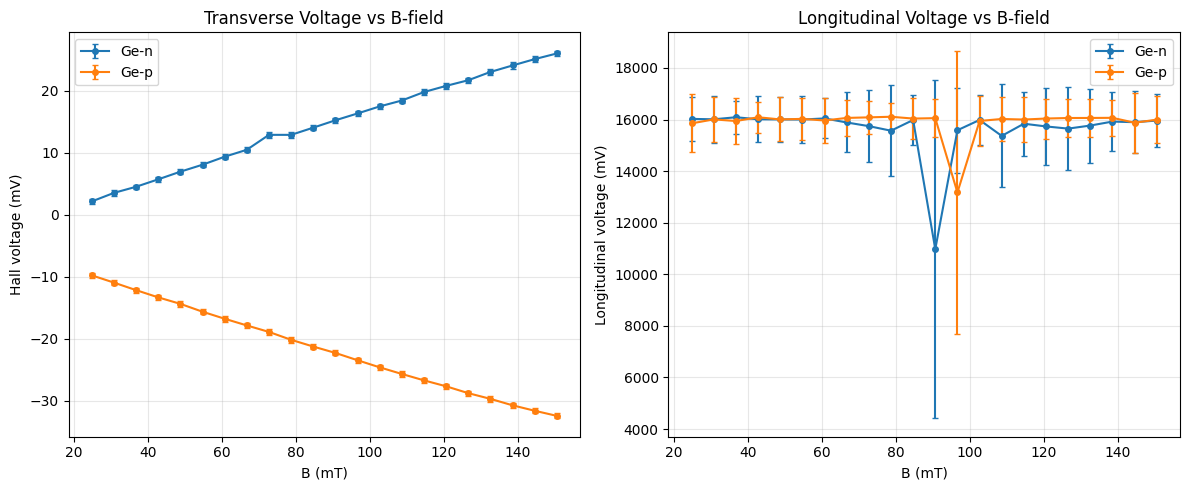

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, mtype in zip(axes, ["transverse", "longitudinal"]):
    for sample in DOPED_SAMPLES:
        B_vals, V_means, V_stds = [], [], []

        for key, d in sorted(ramp_data.items(), key=lambda x: x[1]["I_coil_A"]):
            mt, smp, ck = key
            if mt != mtype or smp != sample:
                continue
            B_vals.append(I_coil_to_B(d["I_coil_A"]))
            V_means.append(d["V_mean"] * 1e3)
            V_stds.append(d["V_std"] * 1e3)

        B_vals = np.array(B_vals)
        V_means = np.array(V_means)
        V_stds = np.array(V_stds)

        ax.errorbar(B_vals, V_means, yerr=V_stds, fmt="o-", markersize=4,
                    capsize=2, label=sample)

    ylabel = "Hall voltage (mV)" if mtype == "transverse" else "Longitudinal voltage (mV)"
    ax.set_xlabel("B (mT)")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{mtype.capitalize()} Voltage vs B-field")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3-1. Sample Current vs Hall Voltage (per B-field)

Transverse 측정의 ramp 구간 데이터를 이용해, 각 B-field(코일 전류 → 변환)별로
샘플 전류 $I_s$ vs 홀 전압 $U_H$ 를 플롯합니다.

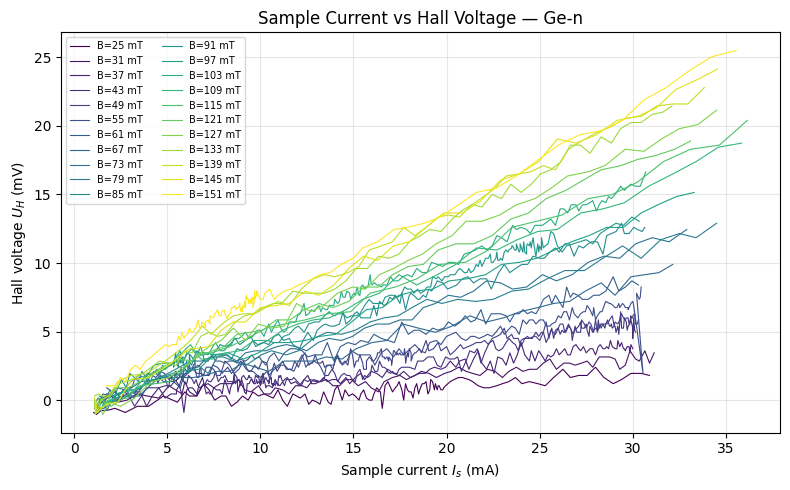

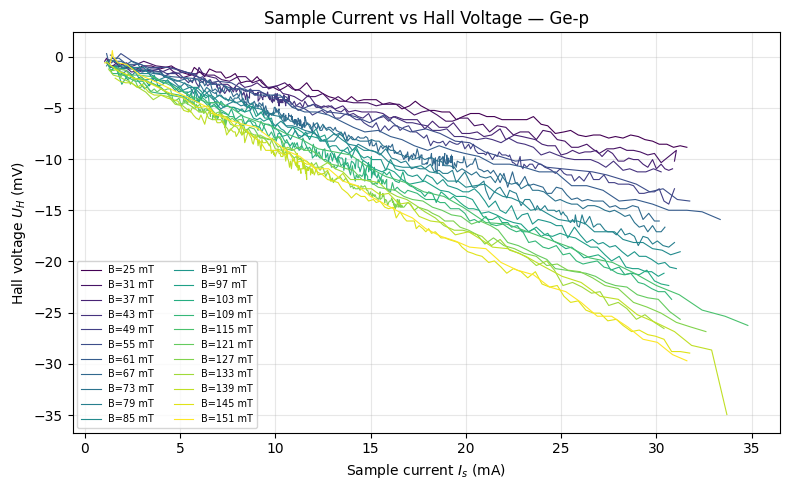

In [50]:
with h5py.File(VOLTAGE_H5, "r") as hf:
    for sample in DOPED_SAMPLES:
        sample_grp = hf[f"transverse/{sample}"]
        coil_keys = sorted(sample_grp.keys(), key=lambda k: int(k.split("_")[1]))

        cmap = plt.cm.viridis
        colors = [cmap(i / (len(coil_keys) - 1)) for i in range(len(coil_keys))]

        fig, ax = plt.subplots(figsize=(8, 5))

        for coil_key, color in zip(coil_keys, colors):
            grp = sample_grp[coil_key]
            I_sample = grp["sample_current_A"][:]
            V_hall = grp["voltage_V"][:]
            I_coil = grp.attrs["coil_current_A"]
            B = I_coil_to_B(I_coil)

            d = ramp_data[("transverse", sample, coil_key)]
            rs, re = d["ramp_start"], d["ramp_end"]

            # ramp region
            I_ramp = I_sample[rs:re]
            V_ramp = V_hall[rs:re]

            # drop NaN
            mask = ~(np.isnan(I_ramp) | np.isnan(V_ramp))
            ax.plot(I_ramp[mask] * 1e3, V_ramp[mask] * 1e3,
                    linewidth=0.8, color=color, label=f"B={B:.0f} mT")

        ax.set_xlabel("Sample current $I_s$ (mA)")
        ax.set_ylabel("Hall voltage $U_H$ (mV)")
        ax.set_title(f"Sample Current vs Hall Voltage — {sample}")
        ax.legend(fontsize=7, ncol=2, loc="best")
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

## 4. 3D Scatter & Hall Coefficient Fit

Hall effect: $U_H = R_H \cdot \frac{I_s \cdot B}{d}$

ramp 구간의 $(I_s, B, U_H)$ 데이터를 3D scatter로 그리고,
$U_H = \frac{R_H}{d} \cdot I_s \cdot B$ 곡면($z = c \cdot xy$) 피팅으로 Hall coefficient $R_H$를 구합니다.

아래 셀에서 샘플 두께 `d`를 수정하세요.

In [51]:
# ---- Sample thickness (edit here) ----
d_m = 1.0e-3  # sample thickness in meters (default 1 mm)
print(f"Sample thickness d = {d_m * 1e3:.2f} mm")

Sample thickness d = 1.00 mm


=== Ge-n ===
  N points  = 2158
  alpha     = 4.6733 +/- 0.0113  V/(A*T)
  R_H       = (46.7334 +/- 0.1129) cm^3/C
  rel. err  = 0.24 %
  residual std = 0.7407 mV



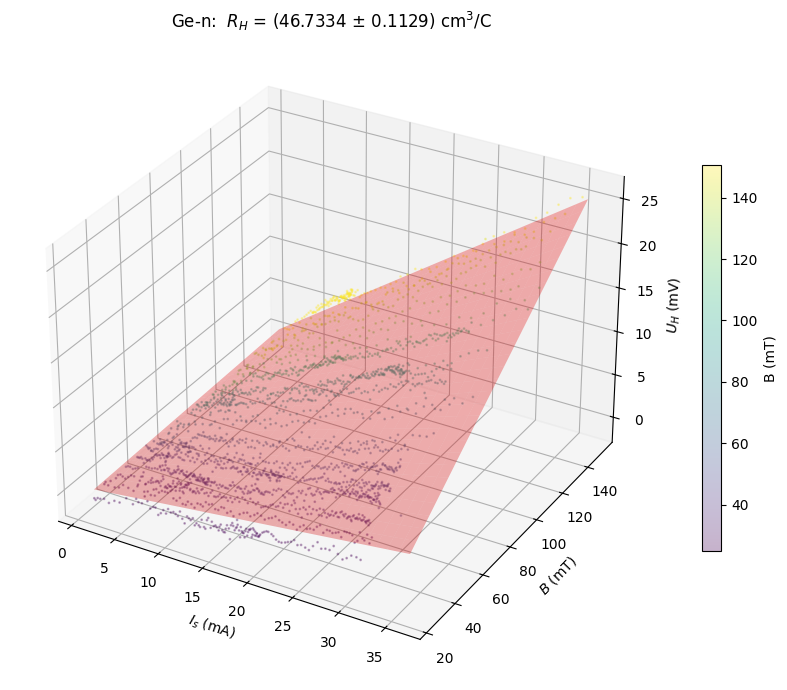

=== Ge-p ===
  N points  = 2647
  alpha     = -7.0617 +/- 0.0156  V/(A*T)
  R_H       = (-70.6168 +/- 0.1563) cm^3/C
  rel. err  = 0.22 %
  residual std = 1.1661 mV



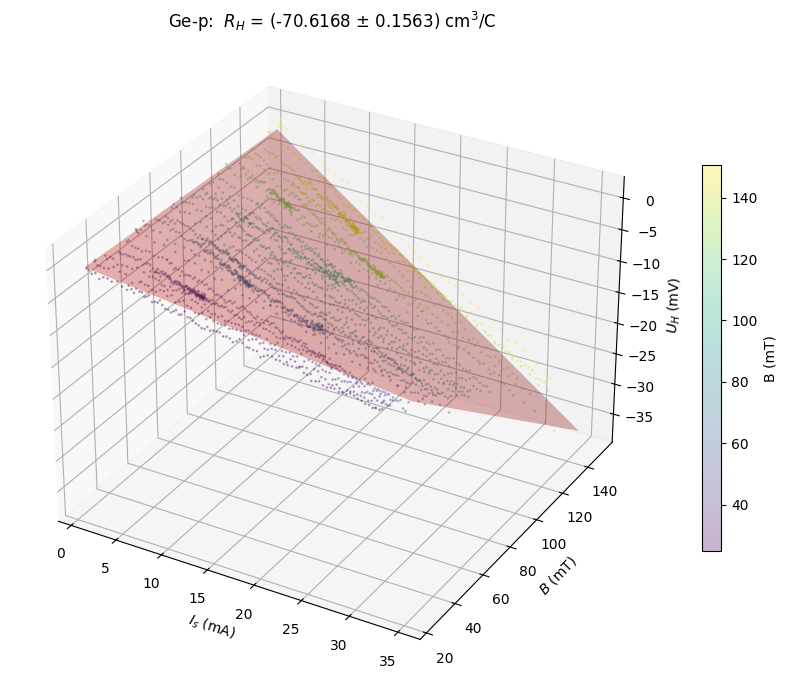


--- Hall Coefficients ---
  Ge-n: R_H = (+46.7334 +/- 0.1129) cm^3/C  ->  hole (p-type)
  Ge-p: R_H = (-70.6168 +/- 0.1563) cm^3/C  ->  electron (n-type)


In [52]:
from mpl_toolkits.mplot3d import Axes3D

hall_coeffs = {}

with h5py.File(VOLTAGE_H5, "r") as hf:
    for sample in DOPED_SAMPLES:
        all_Is, all_B, all_UH = [], [], []

        sample_grp = hf[f"transverse/{sample}"]
        coil_keys = sorted(sample_grp.keys(), key=lambda k: int(k.split("_")[1]))

        for coil_key in coil_keys:
            grp = sample_grp[coil_key]
            I_sample = grp["sample_current_A"][:]
            V_hall = grp["voltage_V"][:]
            I_coil = grp.attrs["coil_current_A"]
            B = I_coil_to_B(I_coil)  # mT

            rd = ramp_data[("transverse", sample, coil_key)]
            rs, re = rd["ramp_start"], rd["ramp_end"]

            I_ramp = I_sample[rs:re]
            V_ramp = V_hall[rs:re]
            mask = ~(np.isnan(I_ramp) | np.isnan(V_ramp))

            all_Is.extend(I_ramp[mask])
            all_B.extend(np.full(mask.sum(), B))
            all_UH.extend(V_ramp[mask])

        Is = np.array(all_Is)   # A
        B_arr = np.array(all_B) # mT
        UH = np.array(all_UH)   # V
        N = len(Is)

        # --- Fit: U_H = alpha * I_s * B,  alpha = R_H / d ---
        B_T = B_arr * 1e-3  # mT -> T
        IB = Is * B_T       # A * T

        # Least squares (origin-constrained)
        sum_IB2 = np.sum(IB**2)
        alpha = np.sum(UH * IB) / sum_IB2

        # Residuals & uncertainty
        UH_pred = alpha * IB
        residuals = UH - UH_pred
        # Standard error of alpha (1-parameter fit through origin: dof = N - 1)
        sigma_alpha = np.sqrt(np.sum(residuals**2) / ((N - 1) * sum_IB2))

        R_H = alpha * d_m           # m^3/C
        sigma_RH = sigma_alpha * d_m  # m^3/C
        hall_coeffs[sample] = {"R_H": R_H, "sigma": sigma_RH}

        print(f"=== {sample} ===")
        print(f"  N points  = {N}")
        print(f"  alpha     = {alpha:.4f} +/- {sigma_alpha:.4f}  V/(A*T)")
        print(f"  R_H       = ({R_H * 1e4:.4f} +/- {sigma_RH * 1e4:.4f}) cm^3/C")
        print(f"  rel. err  = {abs(sigma_RH / R_H) * 100:.2f} %")
        print(f"  residual std = {np.std(residuals) * 1e3:.4f} mV")
        print()

        # --- 3D Scatter + Fit Surface ---
        fig = plt.figure(figsize=(10, 7))
        ax3 = fig.add_subplot(111, projection="3d")

        sc = ax3.scatter(Is * 1e3, B_arr, UH * 1e3,
                         c=B_arr, cmap="viridis", s=1, alpha=0.3)

        # Fit surface: z = alpha * x * y  (hyperbolic paraboloid)
        Is_grid = np.linspace(Is.min(), Is.max(), 30)
        B_grid = np.linspace(B_arr.min(), B_arr.max(), 30)
        Is_mesh, B_mesh = np.meshgrid(Is_grid, B_grid)
        UH_mesh = alpha * Is_mesh * (B_mesh * 1e-3)  # V
        ax3.plot_surface(Is_mesh * 1e3, B_mesh, UH_mesh * 1e3,
                         alpha=0.3, color="red")

        ax3.set_xlabel("$I_s$ (mA)")
        ax3.set_ylabel("$B$ (mT)")
        ax3.set_zlabel("$U_H$ (mV)")
        ax3.set_title(
            f"{sample}:  $R_H$ = ({R_H * 1e4:.4f} $\\pm$ {sigma_RH * 1e4:.4f}) cm$^3$/C"
        )
        fig.colorbar(sc, ax=ax3, label="B (mT)", shrink=0.6)
        plt.tight_layout()
        plt.show()

print("\n--- Hall Coefficients ---")
for sample, vals in hall_coeffs.items():
    R_H, sig = vals["R_H"], vals["sigma"]
    carrier = "hole (p-type)" if R_H > 0 else "electron (n-type)"
    print(f"  {sample}: R_H = ({R_H * 1e4:+.4f} +/- {sig * 1e4:.4f}) cm^3/C  ->  {carrier}")

## 5. Time Series Examples

각 샘플의 transverse(Hall) 전압 시계열 (coil current = 3.0 A)

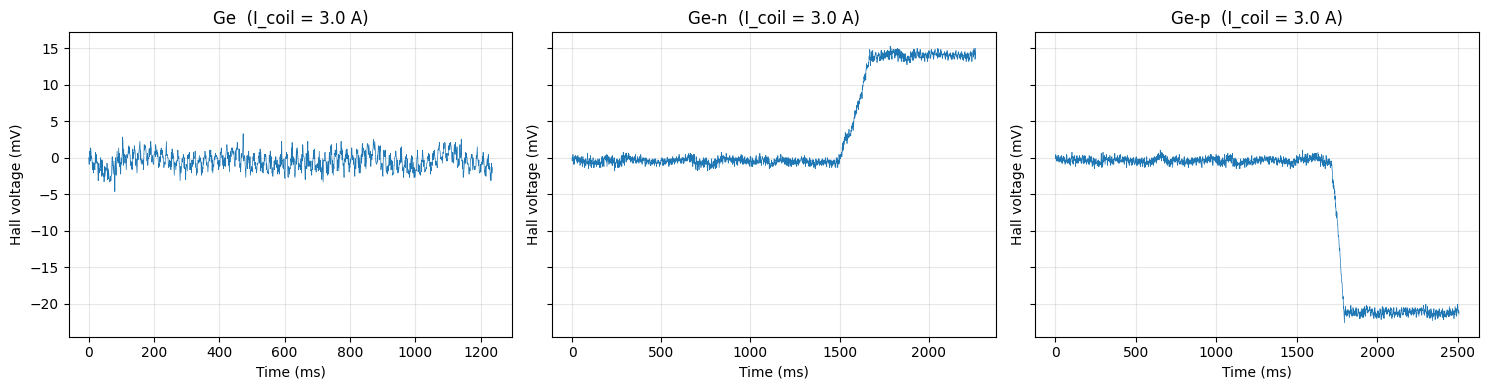

In [53]:
with h5py.File(VOLTAGE_H5, "r") as hf:
    samples = [s for s in hf["transverse"].keys()]
    fig, axes = plt.subplots(1, len(samples), figsize=(5 * len(samples), 4), sharey=True)
    if len(samples) == 1:
        axes = [axes]

    for ax, sample in zip(axes, samples):
        grp = hf[f"transverse/{sample}/coil_30"]
        t = grp["time_s"][:]
        V = grp["voltage_V"][:]
        ax.plot(t * 1e3, V * 1e3, linewidth=0.5)
        ax.set_xlabel("Time (ms)")
        ax.set_ylabel("Hall voltage (mV)")
        ax.set_title(f"{sample}  (I_coil = 3.0 A)")
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## 6. Hall Voltage vs Coil Current

각 샘플에 대해 정상 상태(후반 50%) 평균 transverse 전압 vs 코일 전류

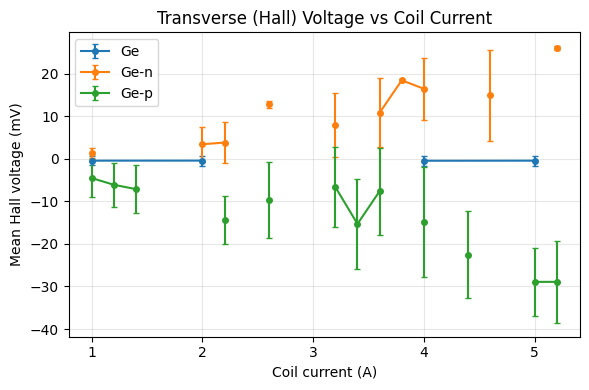

In [54]:
with h5py.File(VOLTAGE_H5, "r") as hf:
    fig, ax = plt.subplots(figsize=(6, 4))

    for sample in sorted(hf["transverse"].keys()):
        sample_grp = hf[f"transverse/{sample}"]
        I_coils, V_means, V_stds = [], [], []

        for coil_key in sorted(sample_grp.keys(), key=lambda k: int(k.split("_")[1])):
            grp = sample_grp[coil_key]
            V = grp["voltage_V"][:]
            V_ss = V[len(V) // 2 :]
            I_coils.append(grp.attrs["coil_current_A"])
            V_means.append(np.mean(V_ss))
            V_stds.append(np.std(V_ss))

        I_coils = np.array(I_coils)
        V_means = np.array(V_means) * 1e3
        V_stds = np.array(V_stds) * 1e3
        ax.errorbar(I_coils, V_means, yerr=V_stds, fmt="o-", markersize=4,
                    capsize=2, label=sample)

    ax.set_xlabel("Coil current (A)")
    ax.set_ylabel("Mean Hall voltage (mV)")
    ax.set_title("Transverse (Hall) Voltage vs Coil Current")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 7. Longitudinal Voltage vs Coil Current

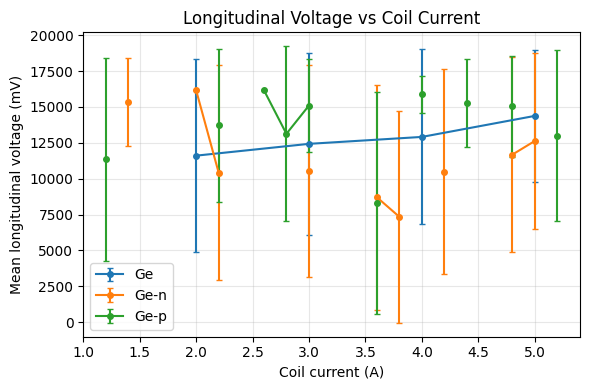

In [55]:
with h5py.File(VOLTAGE_H5, "r") as hf:
    fig, ax = plt.subplots(figsize=(6, 4))

    for sample in sorted(hf["longitudinal"].keys()):
        sample_grp = hf[f"longitudinal/{sample}"]
        I_coils, V_means, V_stds = [], [], []

        for coil_key in sorted(sample_grp.keys(), key=lambda k: int(k.split("_")[1])):
            grp = sample_grp[coil_key]
            V = grp["voltage_V"][:]
            V_ss = V[len(V) // 2 :]
            I_coils.append(grp.attrs["coil_current_A"])
            V_means.append(np.mean(V_ss))
            V_stds.append(np.std(V_ss))

        I_coils = np.array(I_coils)
        V_means = np.array(V_means) * 1e3
        V_stds = np.array(V_stds) * 1e3
        ax.errorbar(I_coils, V_means, yerr=V_stds, fmt="o-", markersize=4,
                    capsize=2, label=sample)

    ax.set_xlabel("Coil current (A)")
    ax.set_ylabel("Mean longitudinal voltage (mV)")
    ax.set_title("Longitudinal Voltage vs Coil Current")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 8. HDF5 Structure Overview

In [56]:
def print_h5_tree(name, obj):
    indent = "  " * name.count("/")
    if isinstance(obj, h5py.Dataset):
        print(f"{indent}{name.split('/')[-1]}  {obj.shape}  {obj.dtype}")
    else:
        attrs = dict(obj.attrs)
        attr_str = f"  attrs={list(attrs.keys())}" if attrs else ""
        print(f"{indent}{name.split('/')[-1]}/{attr_str}")

print("=== voltage_measurements.h5 ===")
with h5py.File(VOLTAGE_H5, "r") as hf:
    hf.visititems(print_h5_tree)

print("\n=== calibration.h5 ===")
with h5py.File(CALIB_H5, "r") as hf:
    hf.visititems(print_h5_tree)

=== voltage_measurements.h5 ===
longitudinal/  attrs=['description', 'voltage_type']
  Ge/  attrs=['description', 'doping']
    coil_10/  attrs=['coil_current_A', 'header_DEC_I_A1', 'header_DEC_U_B1', 'header_DEC_t', 'header_MAX_I_A1', 'header_MAX_U_B1', 'header_MAX_t', 'header_MIN_I_A1', 'header_MIN_U_B1', 'header_MIN_t', 'header_SCALE_I_A1', 'header_SCALE_U_B1', 'header_SCALE_t', 'source_file', 'source_path']
      sample_current_A  (1391,)  float64
      time_s  (1391,)  float64
      voltage_V  (1391,)  float64
    coil_20/  attrs=['coil_current_A', 'header_DEC_I_A1', 'header_DEC_U_B1', 'header_DEC_t', 'header_MAX_I_A1', 'header_MAX_U_B1', 'header_MAX_t', 'header_MIN_I_A1', 'header_MIN_U_B1', 'header_MIN_t', 'header_SCALE_I_A1', 'header_SCALE_U_B1', 'header_SCALE_t', 'source_file', 'source_path']
      sample_current_A  (2065,)  float64
      time_s  (2065,)  float64
      voltage_V  (2065,)  float64
    coil_30/  attrs=['coil_current_A', 'header_DEC_I_A1', 'header_DEC_U_B1', 'head